In [9]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
# pd.set_option('max_columns', 200)

In [10]:
# lectura del dataset
df = pd.read_csv('https://raw.githubusercontent.com/mauricioxavier22/eda_data/refs/heads/main/Metro_Interstate_Traffic_Volume_train.csv')

# **Paso1: entendiendo los datos**

In [11]:
# dimensiones del DataFrame (filas, columnas)
df.shape

(40255, 14)

In [12]:
# devuelve las primera N filas del DataFrame
df.head(5)

,Unnamed: 0,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,hour,traffic_volume
0,0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,09:00,5545
1,1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,10:00,4516
2,2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,11:00,4767
3,3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,12:00,5026
4,4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,13:00,4918


In [13]:
# devuelve o modifica las etiquetas (nombres) de las columnas de un DataFrame
df.columns

Index(['Unnamed: 0', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
       'weather_main', 'weather_description', 'date_time', 'year', 'month',
       'day', 'hour', 'traffic_volume'],
      dtype='object')

In [14]:
# lista el tipo de datos (entero, flotante, texto, etc.) de cada columna en un DataFrame
df.dtypes

,0
Unnamed: 0,int64
holiday,object
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,object
weather_description,object
date_time,object
year,int64


**Descripcion de Atributos**
* holiday: Categórico (Texto),"Indica si el día es festivo (ej. Thanksgiving, Christmas) o un día común."
* temp: Numérico (Continuo),Temperatura media de la región en grados Kelvin.
* rain 1h: Numérico (Continuo),Cantidad de lluvia ocurrida en la última hora (en mm).
* snow 1h: Numérico (Continuo),Cantidad de nieve ocurrida en la última hora (en mm).
* clouds all: Numérico (Discreto),Porcentaje de nubosidad (0 a 100%).
* weather main: Categórico (Texto),"Categoría principal del clima (ej. Clear, Clouds, Rain, Snow)."
* weather description: Categórico (Texto),"Descripción detallada del clima (ej. light rain, scattered clouds)."
* date time: Temporal (DateTime),Fecha y hora del registro (Formato: AAAA-MM-DD HH:MM:SS).
* traffic volume: Numérico (Variable Objetivo),Volumen de tráfico registrado por hora (valores enteros).
  










In [15]:
# resumen que describe la tendencia central, dispersión y forma de la distribución de un conjunto de datos, omitiendo los valores nulos
df.describe()

,Unnamed: 0,temp,rain_1h,snow_1h,clouds_all,year,month,day,traffic_volume
count,40255.00000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000
mean,20127.00000,280.880914,0.376225,0.000266,50.111464,2015.021215,6.788523,15.741697,3259.760303
std,11620.76188,13.229418,49.011416,0.008937,38.883863,1.681899,3.468598,8.720744,1989.592608
min,0.00000,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000
25%,10063.50000,272.325000,0.000000,0.000000,1.000000,2013.000000,4.000000,8.000000,1190.000000
50%,20127.00000,281.800000,0.000000,0.000000,64.000000,2015.000000,7.000000,16.000000,3375.000000
75%,30190.50000,291.250000,0.000000,0.000000,90.000000,2017.000000,10.000000,23.000000,4938.000000
max,40254.00000,308.240000,9831.300000,0.510000,100.000000,2017.000000,12.000000,31.000000,7280.000000


In [16]:
# genera un resumen estadístico exclusivo para las columnas de tipo texto u objeto (Object/String)
df.describe(include=['O'])

,holiday,weather_main,weather_description,date_time,hour
count,51,40255,40255,40255,40255
unique,11,11,38,34042,24
top,Thanksgiving Day,Clouds,sky is clear,2013-04-18 22:00:00,04:00
freq,6,13167,9350,6,1748


In [17]:
# Observaciones:
#Unnamed es probablemente una columna indica, que podria ser eliminada
#algunos datos de temperatura con 0.00 Kelvin, lo cual no es posible, se pueden tratar  en la siguiente seccion.

# **Paso 2: Preparación de los datos**

In [18]:
# Eliminar la columna Unnamed y hour

df = df[[#'Unnamed: 0',
        'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all',
       'weather_main', 'weather_description', 'date_time', 'year', 'month',
       'day',
        #'hour',
        'traffic_volume']].copy()


In [19]:
# Formato de fecha y hora para el campo date_time
df['date_time'] = pd.to_datetime(df['date_time'])
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,4918
...,...,...,...,...,...,...,...,...,...,...,...,...
40250,NaN,249.84,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2017,12,31,2995
40251,NaN,249.79,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2017,12,31,2731
40252,NaN,249.61,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2017,12,31,2483
40253,NaN,249.50,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2017,12,31,2041


In [33]:
# Renombrar columnas
df = df.rename(columns={'holiday':'Feriado',
                        'temp':'Temperatura',
                        'rain_1h':'Lluvia_1h',
                        'snow_1h':'Nieve_1h',
                        'clouds_all':'Nubosidad',
                        'weather_main':'Clima',
                        'weather_description':'Clima_Descripcion',
                        'date_time':'Fecha_hora',
                        'year':'anio',
                        'month':'mes',
                        'day':'dia',
                        'traffic_volume':'Volumen_Trafico'
                       })
df

,Feriado,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Clima,Clima_Descripcion,Fecha_hora,anio,mes,dia,Volumen_Trafico
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,4918
...,...,...,...,...,...,...,...,...,...,...,...,...
40250,NaN,249.84,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2017,12,31,2995
40251,NaN,249.79,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2017,12,31,2731
40252,NaN,249.61,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2017,12,31,2483
40253,NaN,249.50,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2017,12,31,2041


In [34]:
df.isna().sum()

,0
Feriado,40204
Temperatura,0
Lluvia_1h,0
Nieve_1h,0
Nubosidad,0
Clima,0
Clima_Descripcion,0
Fecha_hora,0
anio,0
mes,0


In [35]:
#check % of missing values on df
df1 = (df.isnull().sum()[df.isnull().sum()>0]).to_frame().rename(columns={0:'numero de valores perdidos'})
df1['% de valores perdidos'] = round(100*df1['numero de valores perdidos']/len(df),2)
df1

,numero de valores perdidos,% de valores perdidos
Feriado,40204,99.87


In [36]:
# identificar datos duplicados
df.loc[df.duplicated()]

,Feriado,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Clima,Clima_Descripcion,Fecha_hora,anio,mes,dia,Volumen_Trafico
18697,NaN,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,2015,9,30,3679
23851,NaN,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,2016,6,1,4831
26784,NaN,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,2016,9,21,5365
26980,NaN,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,2016,9,29,3435
27171,NaN,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,2016,10,7,4642
28879,NaN,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,2016,12,6,4520
29268,NaN,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,2016,12,19,420
34711,NaN,295.010,0.0,0.0,40,Clouds,scattered clouds,2017-06-21 11:00:00,2017,6,21,4808
34967,NaN,292.840,0.0,0.0,1,Clear,sky is clear,2017-06-30 10:00:00,2017,6,30,4638
34969,NaN,294.520,0.0,0.0,1,Clear,sky is clear,2017-06-30 11:00:00,2017,6,30,4725


In [37]:
# consultando un ejemplo de dato duplicado
df.query('Temperatura == 289.060')

,Feriado,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Clima,Clima_Descripcion,Fecha_hora,anio,mes,dia,Volumen_Trafico
580,NaN,289.06,0.0,0.0,90,Mist,mist,2012-10-24 19:00:00,2012,10,24,3118
6421,NaN,289.06,0.0,0.0,90,Clouds,overcast clouds,2013-05-26 15:00:00,2013,5,26,3588
6605,NaN,289.06,0.0,0.0,1,Clear,sky is clear,2013-06-02 01:00:00,2013,6,2,787
6870,NaN,289.06,0.0,0.0,92,Mist,mist,2013-06-11 00:00:00,2013,6,11,576
6902,NaN,289.06,0.0,0.0,8,Mist,mist,2013-06-12 01:00:00,2013,6,12,377
17564,NaN,289.06,0.0,0.0,75,Clouds,broken clouds,2015-08-19 19:00:00,2015,8,19,3318
17677,NaN,289.06,0.0,0.0,90,Clouds,overcast clouds,2015-08-23 23:00:00,2015,8,23,1041
17747,NaN,289.06,0.0,0.0,40,Clouds,scattered clouds,2015-08-26 21:00:00,2015,8,26,2812
23850,NaN,289.06,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,2016,6,1,4831
23851,NaN,289.06,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,2016,6,1,4831


In [38]:
# Todas las filas identificadas por df.loc[df.duplicated()] pueden ser borradas

In [39]:
#dropping duplicated rows
df = df.loc[~df.duplicated()] \
    .reset_index(drop=True).copy()
df

,Feriado,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Clima,Clima_Descripcion,Fecha_hora,anio,mes,dia,Volumen_Trafico
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,4918
...,...,...,...,...,...,...,...,...,...,...,...,...
40234,NaN,249.84,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2017,12,31,2995
40235,NaN,249.79,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2017,12,31,2731
40236,NaN,249.61,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2017,12,31,2483
40237,NaN,249.50,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2017,12,31,2041


In [40]:
df.loc[df.duplicated()]
# ya no hay filas duplicadas en el DF

,Feriado,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Clima,Clima_Descripcion,Fecha_hora,anio,mes,dia,Volumen_Trafico


# **Paso 3: Comprension de funciones**

In [41]:
df['Feriado'].value_counts()

,count
Feriado,
Thanksgiving Day,6
Christmas Day,6
Columbus Day,5
Veterans Day,5
New Years Day,5
Labor Day,5
Washingtons Birthday,4
Memorial Day,4
Independence Day,4


In [42]:
df['Clima'].value_counts()

,count
Clima,
Clouds,13162
Clear,11056
Mist,4850
Rain,4680
Snow,2354
Drizzle,1542
Haze,1088
Thunderstorm,765
Fog,720


In [43]:
df['Clima_Descripcion'].value_counts()

,count
Clima_Descripcion,
sky is clear,9344
mist,4850
overcast clouds,4528
broken clouds,4008
scattered clouds,2896
light rain,2824
few clouds,1730
Sky is Clear,1712
light snow,1530


Text(0, 0.5, 'Cuenta')

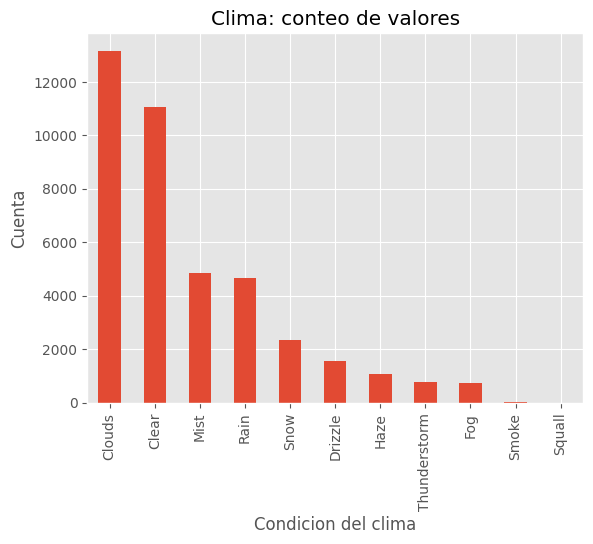

In [44]:
ax = df['Clima'].value_counts() \
     .plot(kind='bar', title='Clima: conteo de valores')
ax.set_xlabel('Condicion del clima')
ax.set_ylabel('Cuenta')

Text(0.5, 0, 'Volumen de Trafico')

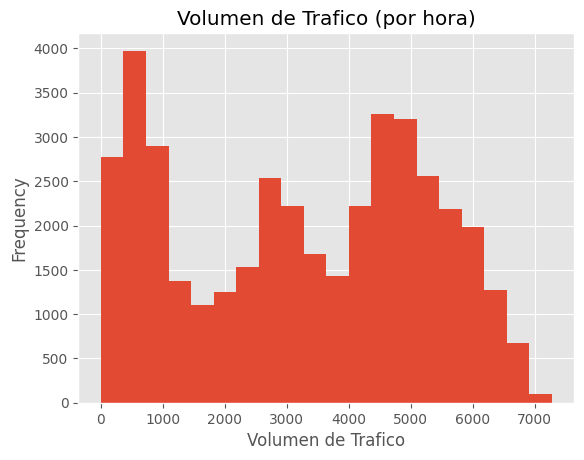

In [45]:
ax = df['Volumen_Trafico'].plot(kind='hist',
                          bins=20,
                          title='Volumen de Trafico (por hora)')
ax.set_xlabel('Volumen de Trafico')

In [46]:
# Se visualizan 3 campanas, lo que indica una distribucion multimodal

Text(0.5, 0, 'Volumen de Trafico (por hora)')

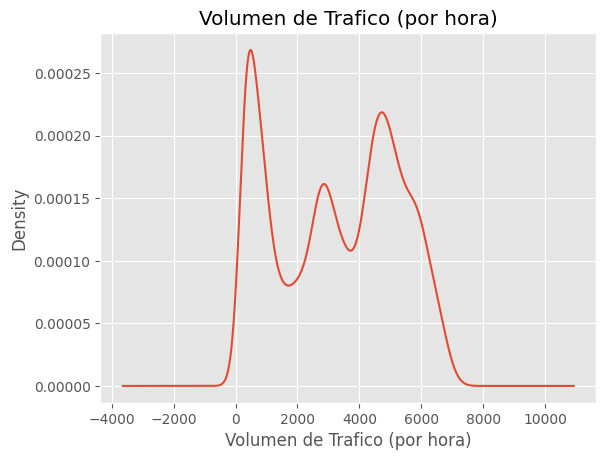

In [47]:
ax = df['Volumen_Trafico'].plot(kind='kde',
                          title='Volumen de Trafico (por hora)')
ax.set_xlabel('Volumen de Trafico (por hora)')

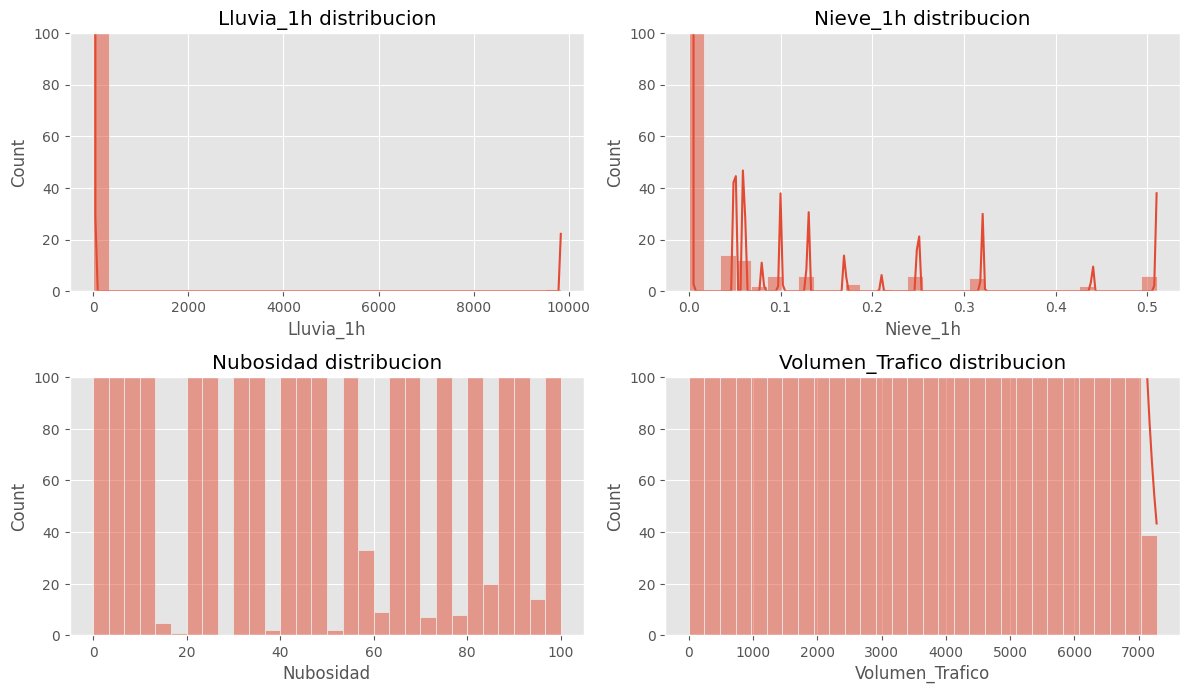

In [48]:
exp_cols = ["Lluvia_1h","Nieve_1h","Nubosidad","Volumen_Trafico"]
plt.figure(figsize=(12,10))
for i, column in enumerate(exp_cols):
    plt.subplot(3,2, i+1)
    sns.histplot(data=df, x=column, kde=True, bins=30)
    plt.title(f'{column} distribucion')
    plt.ylim(0, 100)
    plt.tight_layout()

In [49]:
df.describe()

,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Fecha_hora,anio,mes,dia,Volumen_Trafico
count,40239.000000,40239.000000,40239.000000,40239.000000,40239,40239.000000,40239.000000,40239.000000,40239.000000
mean,280.879723,0.376375,0.000266,50.116628,2015-07-18 10:31:45.345560064,2015.020627,6.787743,15.740550,3259.534382
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,2012.000000,1.000000,1.000000,0.000000
25%,272.320000,0.000000,0.000000,1.000000,2013-11-22 16:30:00,2013.000000,4.000000,8.000000,1190.000000
50%,281.790000,0.000000,0.000000,64.000000,2015-12-21 02:00:00,2015.000000,7.000000,16.000000,3374.000000
75%,291.250000,0.000000,0.000000,90.000000,2017-01-18 11:30:00,2017.000000,10.000000,23.000000,4938.000000
max,308.240000,9831.300000,0.510000,100.000000,2017-12-31 23:00:00,2017.000000,12.000000,31.000000,7280.000000
std,13.229791,49.021159,0.008939,38.883109,NaN,1.681930,3.468748,8.719388,1989.683145


# **Paso 4: Relacionamiento**

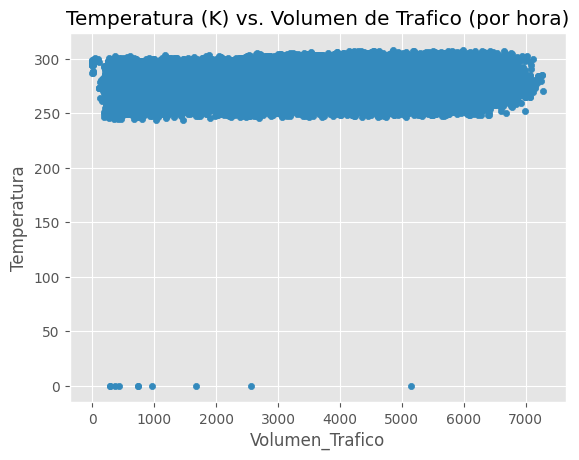

In [50]:
df.plot(kind='scatter',
        x='Volumen_Trafico',
        y='Temperatura',
        title='Temperatura (K) vs. Volumen de Trafico (por hora)')
plt.show()

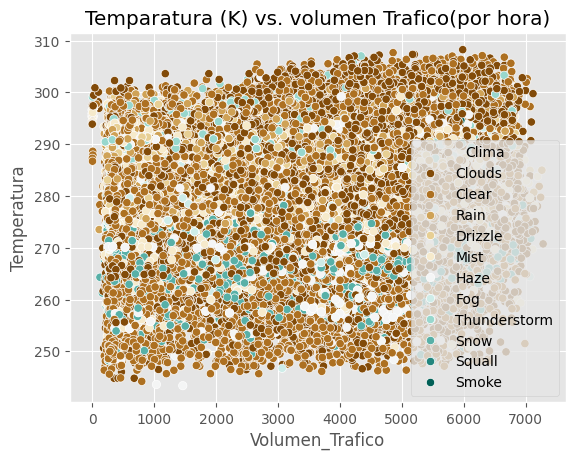

In [51]:
df_filtered = df[df['Temperatura'] != 0]

ax = sns.scatterplot(x='Volumen_Trafico',
                y='Temperatura',
                hue='Clima',
                palette ='BrBG',
                data=df_filtered)
ax.set_title('Temparatura (K) vs. volumen Trafico(por hora)')
plt.show()

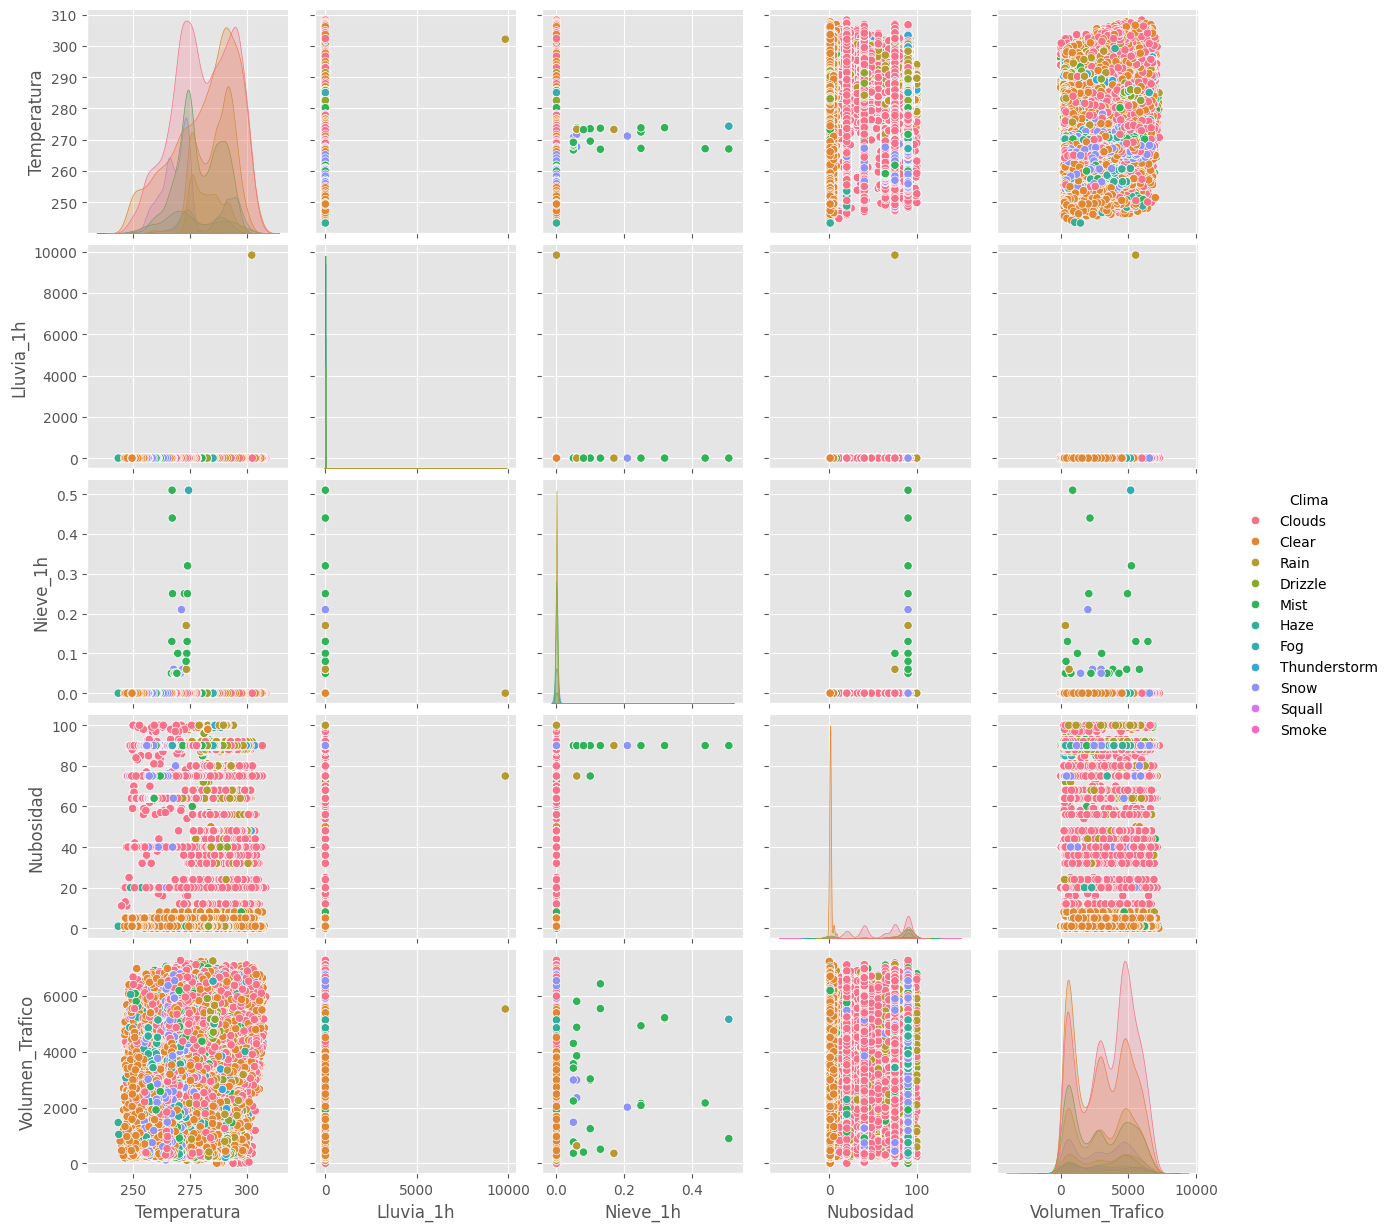

In [52]:
sns.pairplot(df_filtered,
             vars=['Temperatura','Lluvia_1h',
                   'Nieve_1h','Nubosidad','Volumen_Trafico'],
            hue='Clima')
plt.show()


<Axes: >

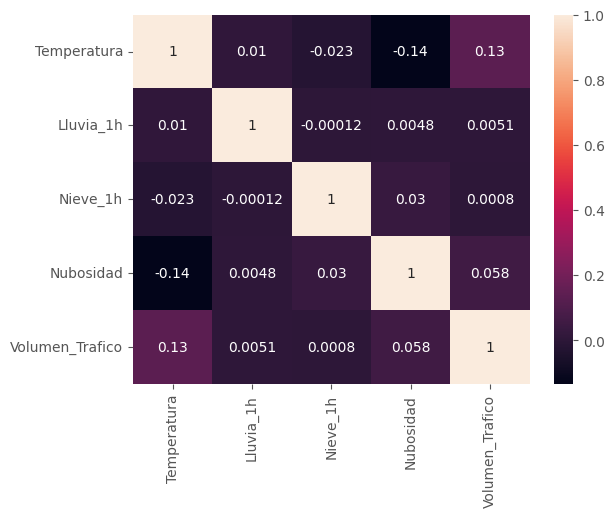

In [53]:
df_corr = df_filtered[['Temperatura','Lluvia_1h',
            'Nieve_1h','Nubosidad','Volumen_Trafico']].dropna().corr()
df_corr
sns.heatmap(df_corr, annot=True)

In [54]:
# Graficas basadas en datos de tiempo:

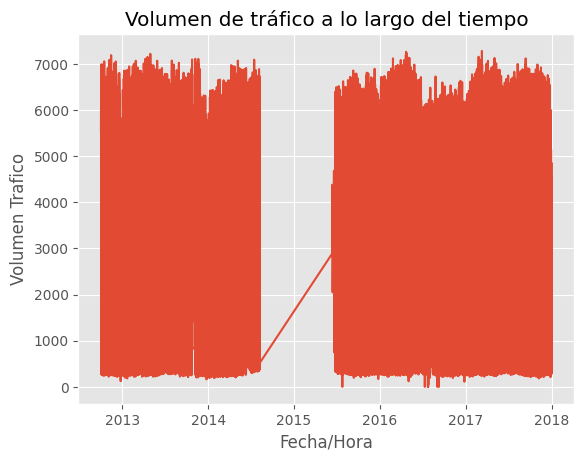

In [55]:
sns.lineplot(x='Fecha_hora', y='Volumen_Trafico', data=df)
plt.title('Volumen de tráfico en el tiempo')
plt.xlabel('Fecha/Hora')
plt.ylabel('Volumen Trafico')
plt.show()

In [56]:
# Se puede notar que hay una falta de informacion para 2015

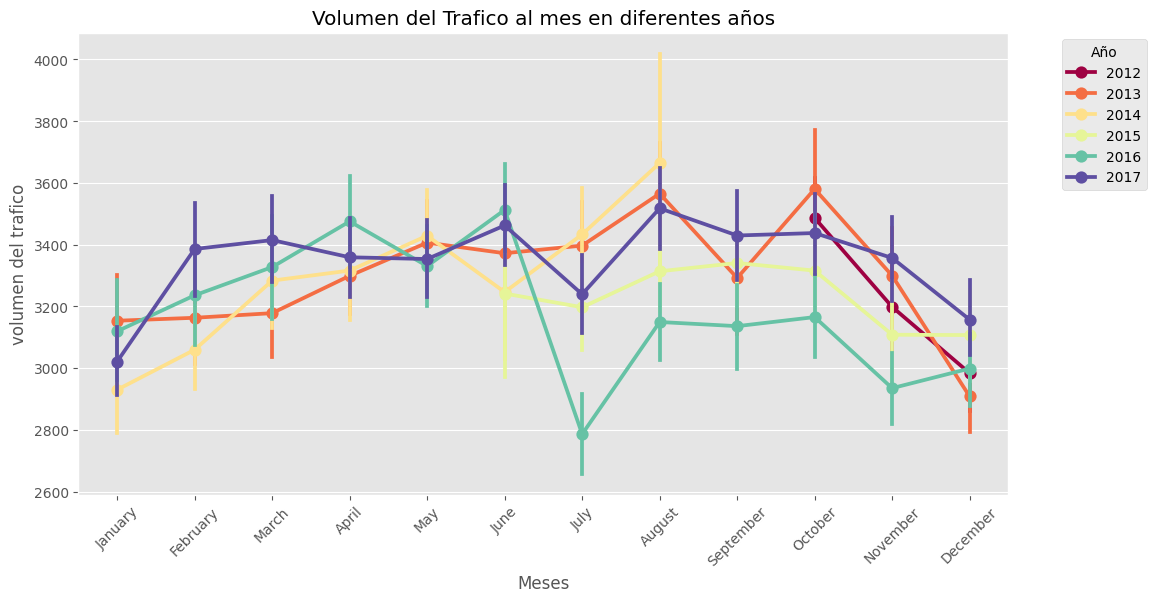

In [57]:
# Extraer año y mes del campo Fecha_Hora
df['Year'] = df['Fecha_hora'].dt.year
df['Month'] = df['Fecha_hora'].dt.month_name()

# Set the order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))  # Set the figure size

# Line plot with hues for different years
sns.pointplot(x='Month', y='Volumen_Trafico', hue='Year', data=df, palette='Spectral')
plt.title('Volumen del Trafico al mes en diferentes años')
plt.xlabel('Meses')
plt.ylabel('volumen del trafico')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

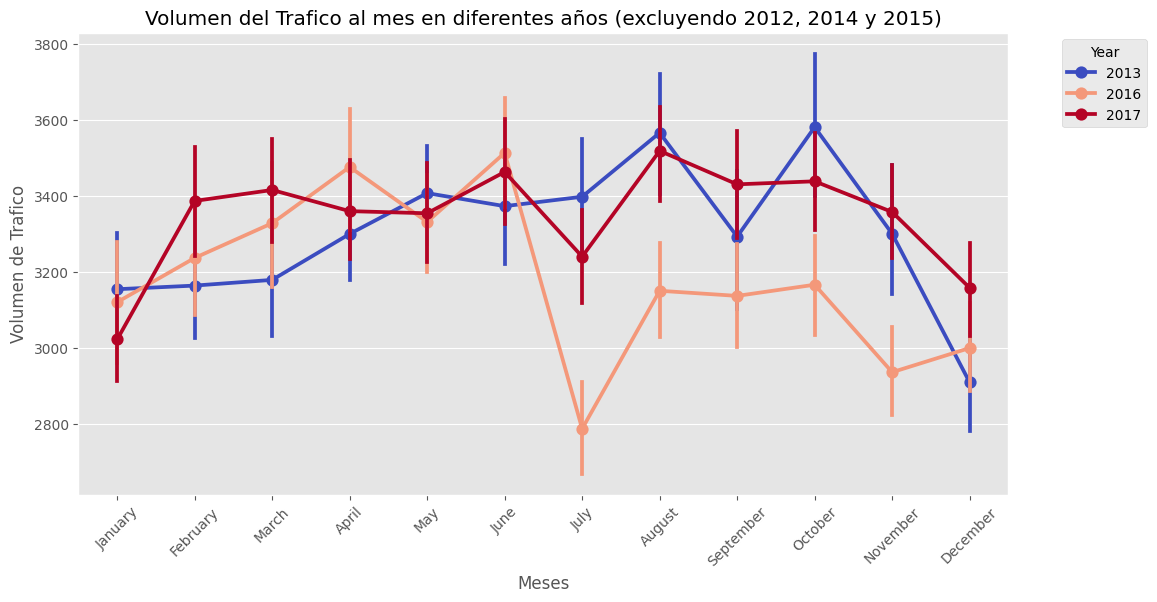

In [58]:
# Datos filtrados de los años 2012, 2014 y 2015
df_filtered = df[(df['Year'] != 2012) & (df['Year'] != 2014) & (df['Year'] != 2015)]

plt.figure(figsize=(12, 6))  # Set the figure size

# Line plot with hues for different years
sns.pointplot(x='Month', y='Volumen_Trafico', hue='Year', data=df_filtered, palette='coolwarm')
plt.title('Volumen del Trafico al mes en diferentes años (excluyendo 2012, 2014 y 2015)')
plt.xlabel('Meses')
plt.ylabel('Volumen de Trafico')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# **Paso 5: Preguntas acerca de los datos**
* Por que el volumen de trafico en 2016 de (Jul to Dec) se ve mucho mas bajo que otros años?

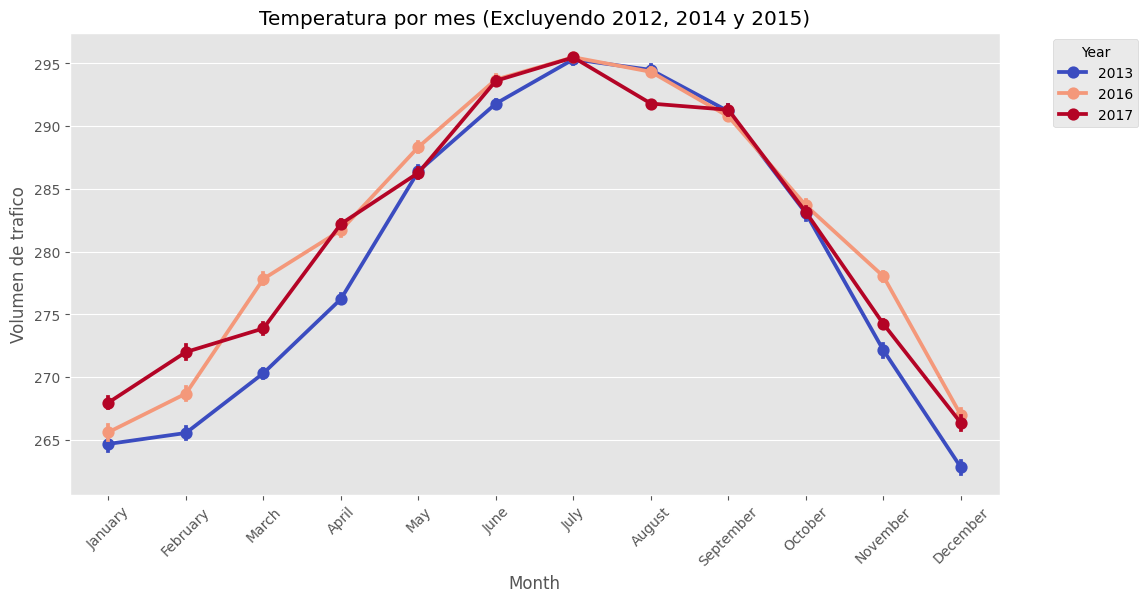

In [64]:
# Excusion de los datos de los años 2012, 2014, 2015
df_filtered = df[(df['Year'] != 2012) & (df['Year'] != 2014) & (df['Year'] != 2015)]

plt.figure(figsize=(12, 6))  # Set the figure size


# Line plot with hues for different years
sns.pointplot(x='Month', y='Temperatura', hue='Year', data=df_filtered, palette='coolwarm')

plt.title('Temperatura por mes (Excluyendo 2012, 2014 y 2015)')
plt.xlabel('Month')
plt.ylabel('Volumen de trafico')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


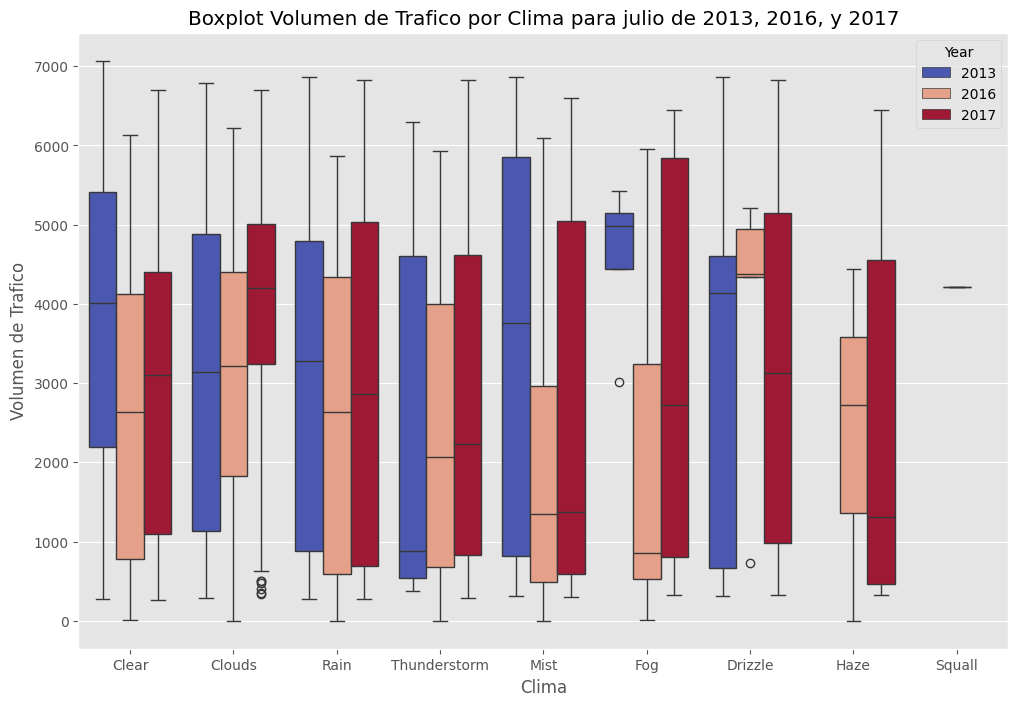

In [67]:
# Filter out data for the years 2013, 2016, and 2017 for the month of July
df_july = df[((df['Year'] == 2013) | (df['Year'] == 2016) | (df['Year'] == 2017)) & (df['Month'] == 'July')]

plt.figure(figsize=(12, 8))  # Set the figure size

# Boxplot for Traffic_Volume by Weather_Main for the month of July in 2013, 2016, and 2017
sns.boxplot(x='Clima', y='Volumen_Trafico', hue='Year', data=df_july, palette='coolwarm')
plt.title('Boxplot Volumen de Trafico por Clima para julio de 2013, 2016, y 2017')
plt.xlabel('Clima')
plt.ylabel('Volumen de Trafico')
plt.show()

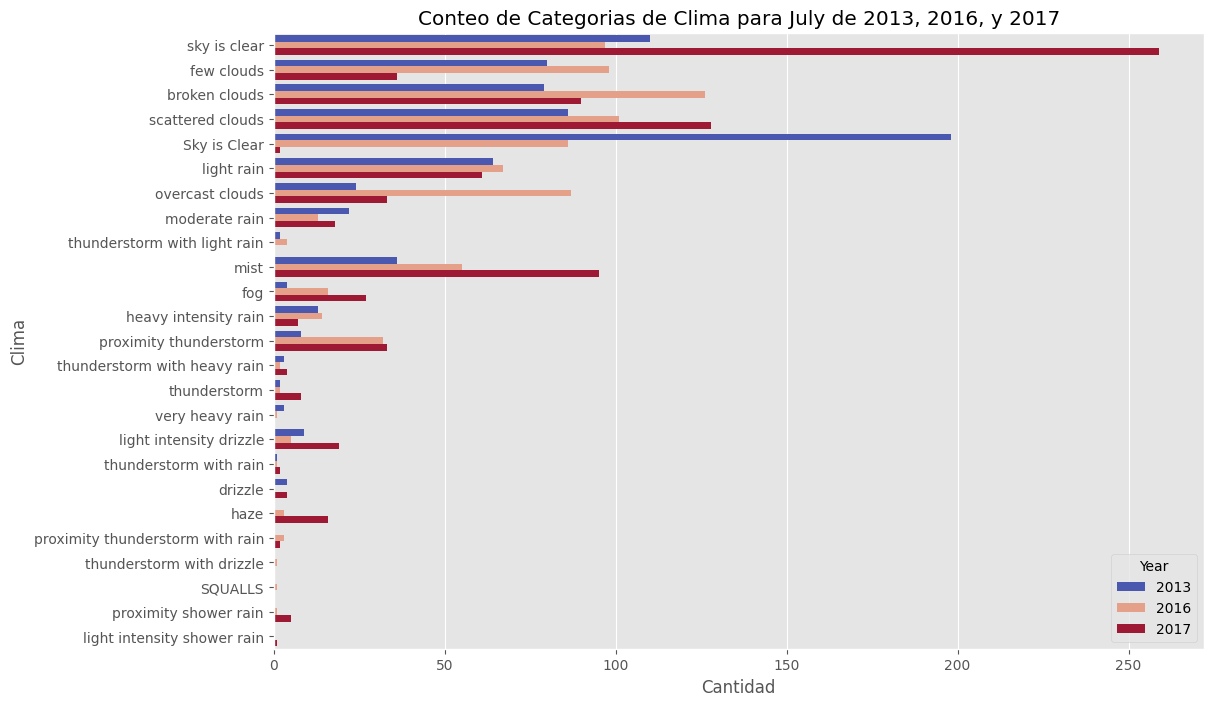

In [69]:
plt.figure(figsize=(12, 8))  # Set the figure size

# Countplot for Weather_Description for the month of July in 2013, 2016, and 2017
sns.countplot(y='Clima_Descripcion', hue='Year', data=df_july, palette='coolwarm')
plt.title('Conteo de Categorias de Clima para July de 2013, 2016, y 2017')
plt.ylabel('Clima')
plt.xlabel('Cantidad')
plt.show()

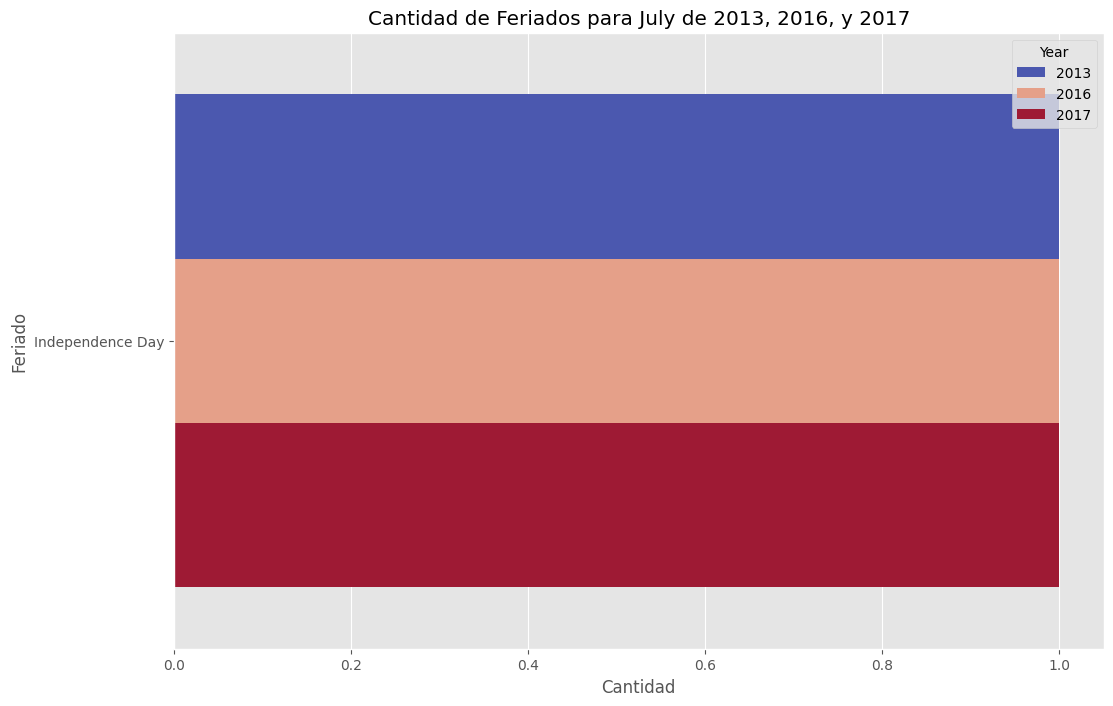

In [71]:
plt.figure(figsize=(12, 8))  # Set the figure size

# Countplot for Holiday for the month of July in 2013, 2016, and 2017
sns.countplot(y='Feriado', hue='Year', data=df_july, palette='coolwarm')
plt.title('Cantidad de Feriados para July de 2013, 2016, y 2017')
plt.ylabel('Feriado')
plt.xlabel('Cantidad')
plt.show()

In [72]:
df

,Feriado,Temperatura,Lluvia_1h,Nieve_1h,Nubosidad,Clima,Clima_Descripcion,Fecha_hora,anio,mes,dia,Volumen_Trafico,Year,Month
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,5545,2012,October
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,4516,2012,October
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,4767,2012,October
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,5026,2012,October
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,4918,2012,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40234,NaN,249.84,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2017,12,31,2995,2017,December
40235,NaN,249.79,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2017,12,31,2731,2017,December
40236,NaN,249.61,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2017,12,31,2483,2017,December
40237,NaN,249.50,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2017,12,31,2041,2017,December
